# Assignment 2

- WB3: Western Boundary mooring 3
- MAR: Mid-Atlantic Ridge

In [1]:
import numpy as np
# from amoc_analysis.correlation_trends.correlation import autocorr

%load_ext autoreload

## Part 1 - Geostrophic transport

- compute upper-mid-ocean (UMO) geostrophic transport
- compare UMO geostr. transport with TRANS_UMO

### Read data

In [2]:
from amocatlas import read
from amoc_analysis.correlation_trends.data_io import load_ts_gridded

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()
trans_umo = transports.TRANS_UMO

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)
ts = read.rapid(file_list=["ts_gridded.nc"], transport_only=False)

# 26N overturning in density coordinates: MOC_SIGMA0
# mt = read.rapid(file_list=["meridional_transports.nc"], transport_only=False)

# 47N NOAC overturning (monthly): MOC_SIGMA0
# noac = read.read_47n()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

Loading 1 RAPID 26°N dataset(s):
  0. ts_gridded.nc: RAPID gridded temperature and salinity



In [3]:
ts

<xarray.Dataset> Size: 509MB
Dimensions:            (depth: 242, TIME: 14599)
Coordinates:
    PRESSURE           (depth) float64 2kB ...
  * TIME               (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Dimensions without coordinates: depth
Data variables: (12/18)
    TEMP_WEST          (depth, TIME) float64 28MB ...
    PSAL_WEST          (depth, TIME) float64 28MB ...
    TEMP_WB3           (depth, TIME) float64 28MB ...
    PSAL_WB3           (depth, TIME) float64 28MB ...
    TEMP_EAST          (depth, TIME) float64 28MB ...
    PSAL_EAST          (depth, TIME) float64 28MB ...
    ...                 ...
    TEMP_EAST_FLAG     (depth, TIME) float64 28MB ...
    PSAL_EAST_FLAG     (depth, TIME) float64 28MB ...
    TEMP_MARWEST_FLAG  (depth, TIME) float64 28MB ...
    PSAL_MARWEST_FLAG  (depth, TIME) float64 28MB ...
    TEMP_MAREAST_FLAG  (depth, TIME) float64 28MB ...
    PSAL_MAREAST_FLAG  (depth, TIME) float64 28MB ...
Attributes: (12/40)
    title:                                 RAPID streamfunction
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Open Government Licence v3.0 ht...
    ...                                    ...
    variable_mapping:                      {'time': 'TIME', 'TG_west': 'TEMP_...
    original_variable_metadata:            {'TG_west': {'long_name': 'Tempera...
    applied_variable_mapping:              {'time': 'TIME', 'TG_west': 'TEMP_...
    version:                               v2024.1a
    files:                                 {'moc_transports.nc': {'featureTyp...
    convert_to_coord:                      pressure

### Dynamic height

In [4]:
# %autoreload
from amoc_analysis.correlation_trends.geostrophy import dynamic_height, to_teos10

# Add TIME dimension to pressure
pressure_grid = ts.PRESSURE.expand_dims(dim={'TIME': ts.TIME.values}, axis=1)

lat_west, lon_west =  26.52, -76.74
lat_east, lon_east =  26.99, -16.23

# Get absolute salinity and conservative temp
sa_west, ct_west = to_teos10(temp=ts.TEMP_WEST, salt=ts.PSAL_WEST, pres=pressure_grid, lon=lon_west, lat=lat_west)
sa_east, ct_east = to_teos10(temp=ts.TEMP_EAST, salt=ts.PSAL_EAST, pres=pressure_grid, lon=lon_east, lat=lat_east)

# Compute dynamical height at each depth and each timestap
dyn_height_west = dynamic_height(SA=sa_west, CT=ct_west, pres=pressure_grid)
dyn_height_east = dynamic_height(SA=sa_east, CT=ct_east, pres=pressure_grid)

### Zonally integrated geostrophic transport

In [5]:
%autoreload
from amoc_analysis.correlation_trends.geostrophy import interior_geostrophic_transport

trans_umo_diy = interior_geostrophic_transport(ds=ts, lat=lat_west, z_max=1100)

In [6]:
trans_umo_diy

<xarray.DataArray 'interior_geostrophic_transport' (TIME: 14599)> Size: 117kB
array([-13.23429458, -11.80161144,  -9.63593805, ..., -12.25587576,
       -10.51528383, -10.01273843], shape=(14599,))
Coordinates:
  * TIME     (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Attributes:
    units:                Sv
    long_name:            Upper mid-ocean geostrophic transport
    reference_pressure:   4820.0
    integration_depth_m:  1100

- ``(phi_east - phi_west) / f``: zonally-integrated geostrophic transport per unit depth (horizontal distance cancels between thermal-wind velocity and its zonal integral)

-> still differs from the published ``TRANS_UMO`` (correlation ~0.77):
- official product also splits the interior at the Mid-Atlantic Ridge, applies a mass-balance adjustment, and uses the time-varying AMOC-maximum depth

### Compare with `TRANS_UMO`

#### Overlayed time series

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Upper mid-ocean'}, xlabel='Time', ylabel='Upper mid-ocean [Sverdrup]'>)

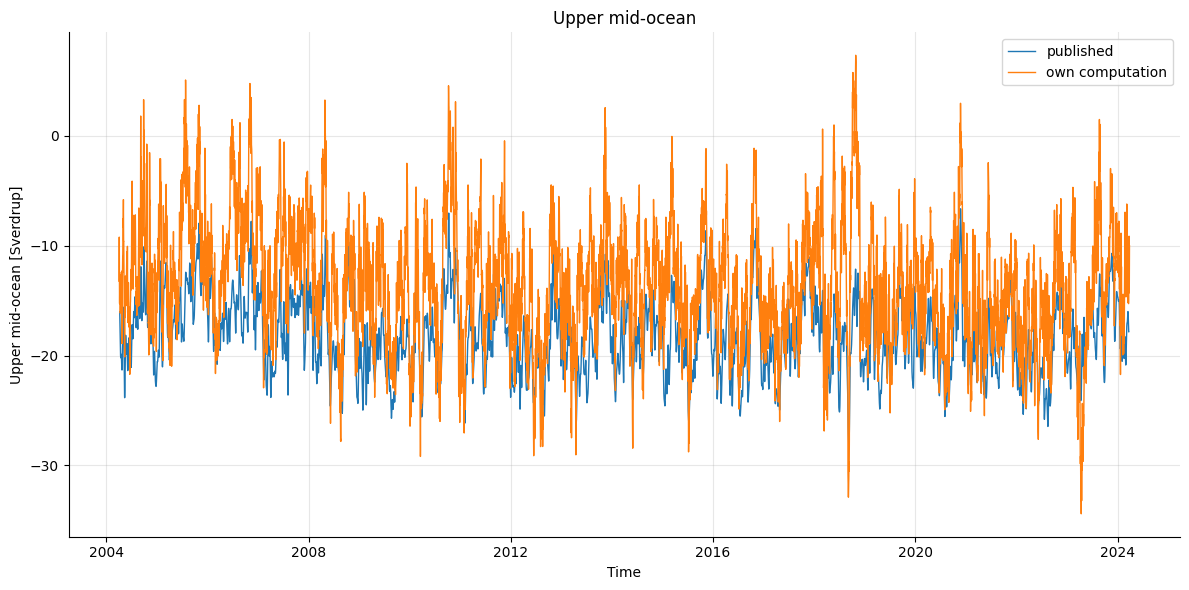

In [7]:
%autoreload
from amoc_analysis.plotting import plot_time_series_from_dataarray

plot_time_series_from_dataarray(
    da=[trans_umo, trans_umo_diy],
    labels=['published', 'own computation'],)

#### Correlation

In [8]:
%autoreload
from amoc_analysis.correlation_trends.correlation import cross_correlation
from scipy import stats

lags, r = cross_correlation(trans_umo_diy, trans_umo)

# Find correlation at zero lag
idx = np.where(lags == 0)[0][0]
print(f'Correlation at lag 0: {r[idx]:.2f}')

Correlation at lag 0: 0.76


In [9]:
# lags, r

In [10]:
sum(np.isnan(trans_umo.values)), sum(np.isnan(trans_umo_diy.values))

(np.int64(20), np.int64(0))

#### Scatter plot with regression line

Slope of regression line: 1.23


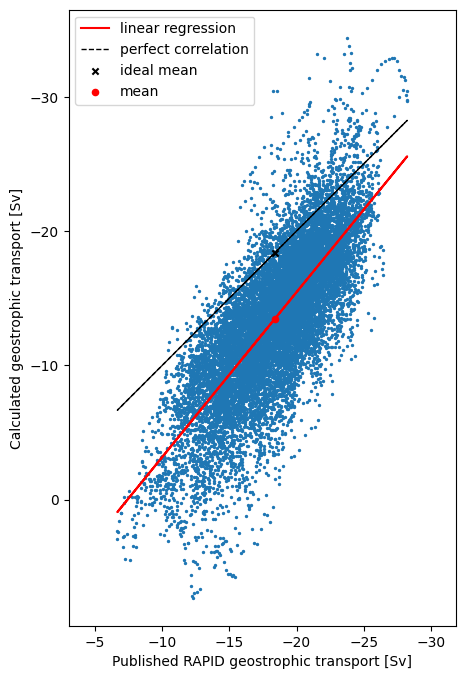

In [11]:
import matplotlib.pyplot as plt

# Remove NaNs
mask = ~(np.isnan(trans_umo.values) | np.isnan(trans_umo_diy.values))
x = trans_umo.values[mask]
y = trans_umo_diy.values[mask]

fig, ax = plt.subplots(figsize=(5,8))

# Scatter plot
ax.scatter(x, y, s=8, marker='.')

# Regression line
slope, b = np.polyfit(x,y,1)
print(f'Slope of regression line: {slope:.2f}')
plt.plot(x, slope*x+b, c='r', label='linear regression')

# Perfect match
plt.plot(x, x, lw=1, ls='--', c='k', label='perfect correlation')

# Means
plt.scatter(np.mean(x), np.mean(x), s=20, c='k', marker='x', label='ideal mean')
plt.scatter(np.mean(x), np.mean(y), s=20, c='r', marker='o', label='mean')

# Fig settings
# plt.ylim(minvval, maxval)
ax.axis('equal')
ax.xaxis.set_inverted(True)
ax.yaxis.set_inverted(True)
plt.xlabel('Published RAPID geostrophic transport [Sv]')
plt.ylabel('Calculated geostrophic transport [Sv]')

plt.legend()

plt.show()


- estimated transport has larger range than published -> higher variance, std
- lin reg has larger slope than perfect correlation -> higher variance
- lin reg (and mean) lower than ideal -> underestimates geostrophic transport (minus is just direction)

- published product splits interior into west and east of MAR + applies mass-balance adjustment
- published product accounts for wind-driven surface flow (Ekman) through mass balance (?)